
# Sesión 02 — Modelos de Clasificación
**Ingeniería del Conocimiento (ISO56B)** · UNCP · 2026-II

**Docente:** Msc. Jaime Antonio Huaytalla Pariona

**Dataset:** Breast Cancer Wisconsin (569 muestras, 30 features, clasificación binaria)

---

## 1. Configuración del entorno

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score, roc_curve, auc,
    ConfusionMatrixDisplay, RocCurveDisplay
)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('✓ Librerías cargadas correctamente')

✓ Librerías cargadas correctamente


---
## 2. Carga y exploración del dataset

El dataset **Breast Cancer Wisconsin** contiene 569 muestras de biopsias de mama con 30 features numéricas computadas a partir de imágenes digitalizadas de aspiración con aguja fina (FNA). El target es binario: **maligno (0)** o **benigno (1)**.

In [2]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df['diagnosis'] = df['target'].map({0: 'maligno', 1: 'benigno'})

print(f'Dataset: {df.shape[0]} muestras, {df.shape[1]-2} features')
print(f'\nDistribución de clases:')
print(df['diagnosis'].value_counts())
print(f'\nProporción: {df["target"].mean():.1%} benigno, {1-df["target"].mean():.1%} maligno')

Dataset: 569 muestras, 30 features

Distribución de clases:
diagnosis
benigno    357
maligno    212
Name: count, dtype: int64

Proporción: 62.7% benigno, 37.3% maligno


In [3]:
df.describe().round(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,...,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000
mean,14.127,19.290,91.969,654.889,0.096,0.104,0.089,0.049,0.181,0.063,...,25.677,107.261,880.583,0.132,0.254,0.272,0.115,0.290,0.084,0.627
std,3.524,4.301,24.299,351.914,0.014,0.053,0.080,0.039,0.027,0.007,...,6.146,33.603,569.357,0.023,0.157,0.209,0.066,0.062,0.018,0.484
min,6.981,9.710,43.790,143.500,0.053,0.019,0.000,0.000,0.106,0.050,...,12.020,50.410,185.200,0.071,0.027,0.000,0.000,0.156,0.055,0.000
25%,11.700,16.170,75.170,420.300,0.086,0.065,0.030,0.020,0.162,0.058,...,21.080,84.110,515.300,0.117,0.147,0.114,0.065,0.250,0.071,0.000
50%,13.370,18.840,86.240,551.100,0.096,0.093,0.062,0.034,0.179,0.062,...,25.410,97.660,686.500,0.131,0.212,0.227,0.100,0.282,0.080,1.000
75%,15.780,21.800,104.100,782.700,0.105,0.130,0.131,0.074,0.196,0.066,...,29.720,125.400,1084.000,0.146,0.339,0.383,0.161,0.318,0.092,1.000
max,28.110,39.280,188.500,2501.000,0.163,0.345,0.427,0.201,0.304,0.097,...,49.540,251.200,4254.000,0.223,1.058,1.252,0.291,0.664,0.208,1.000


---
## 3. Análisis exploratorio orientado a clasificación

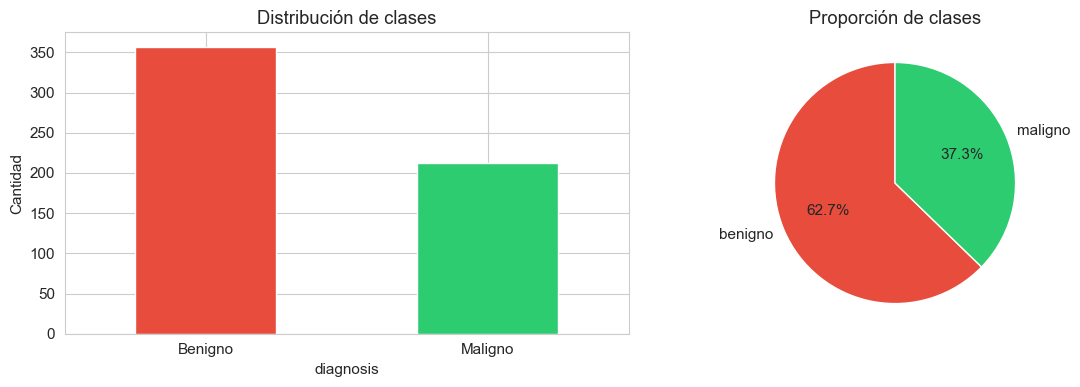

In [4]:
# 3.1  Distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Conteo
colors = ['#e74c3c', '#2ecc71']
df['diagnosis'].value_counts().plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Distribución de clases')
axes[0].set_ylabel('Cantidad')
axes[0].set_xticklabels(['Benigno', 'Maligno'], rotation=0)

# Pie chart
df['diagnosis'].value_counts().plot(kind='pie', ax=axes[1], colors=colors,
    autopct='%1.1f%%', startangle=90)
axes[1].set_ylabel('')
axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.show()

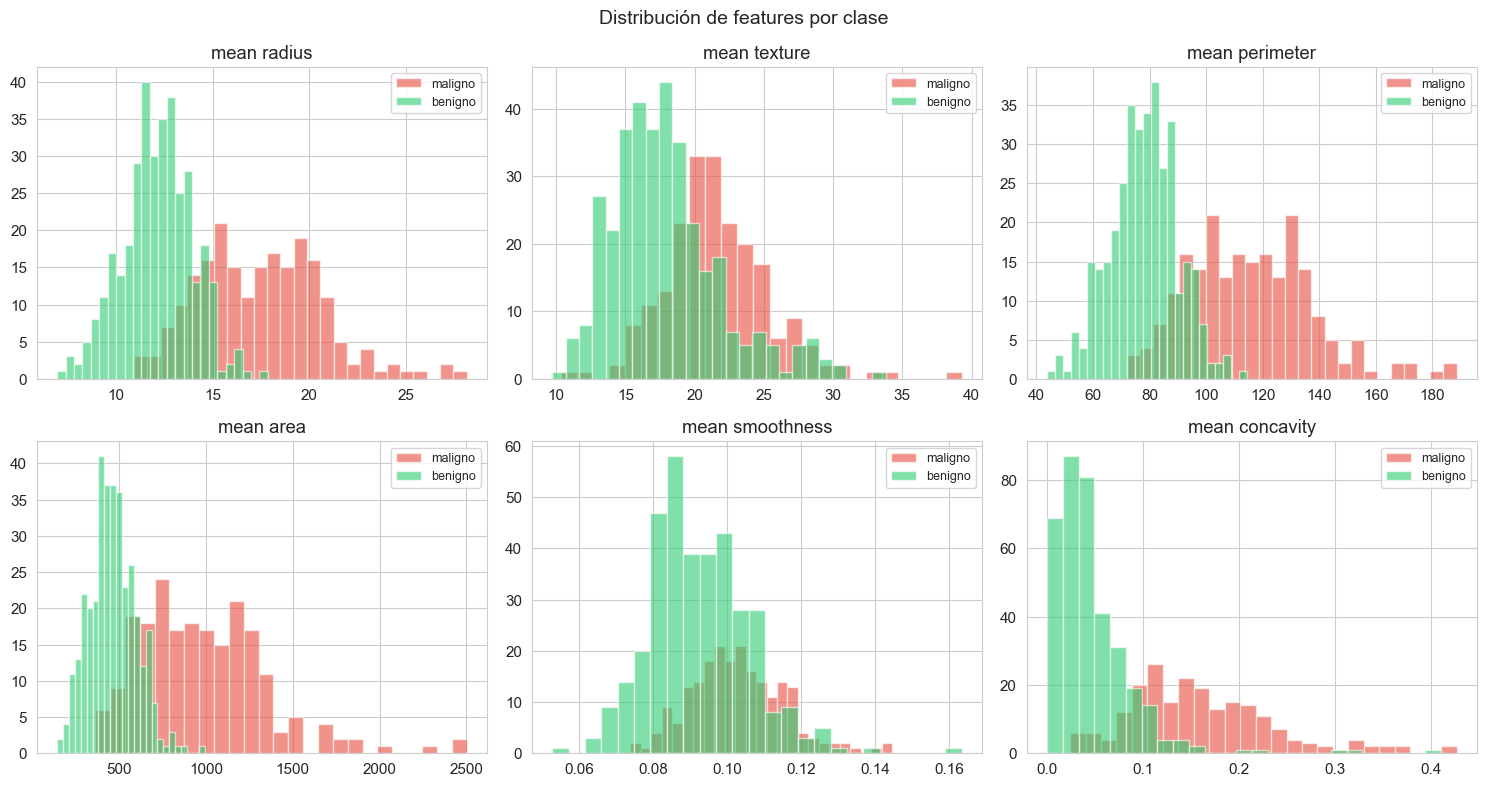

In [5]:
# 3.2  Distribución de features clave por clase
key_features = ['mean radius', 'mean texture', 'mean perimeter',
                'mean area', 'mean smoothness', 'mean concavity']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, feat in enumerate(key_features):
    ax = axes[i//3, i%3]
    for label, color in zip([0, 1], colors):
        subset = df[df['target'] == label][feat]
        ax.hist(subset, bins=25, alpha=0.6, color=color,
                label='maligno' if label == 0 else 'benigno')
    ax.set_title(feat)
    ax.legend(fontsize=9)

plt.suptitle('Distribución de features por clase', fontsize=14)
plt.tight_layout()
plt.show()

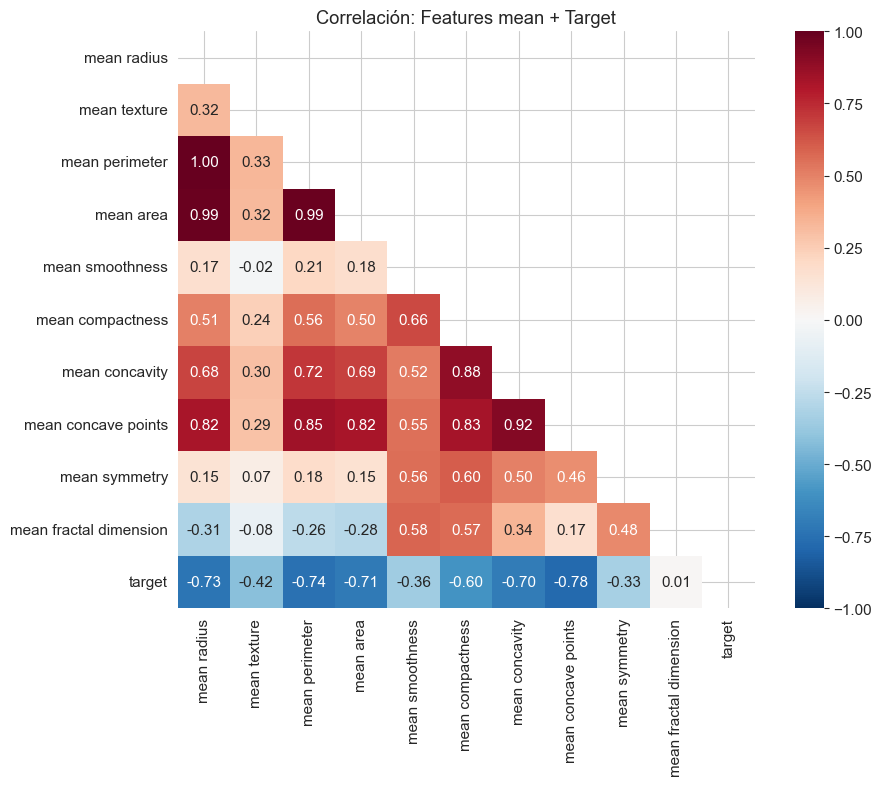

In [6]:
# 3.3  Matriz de correlación (features mean)
mean_features = [c for c in df.columns if 'mean' in c]
plt.figure(figsize=(10, 8))
corr = df[mean_features + ['target']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True)
plt.title('Correlación: Features mean + Target')
plt.tight_layout()
plt.show()

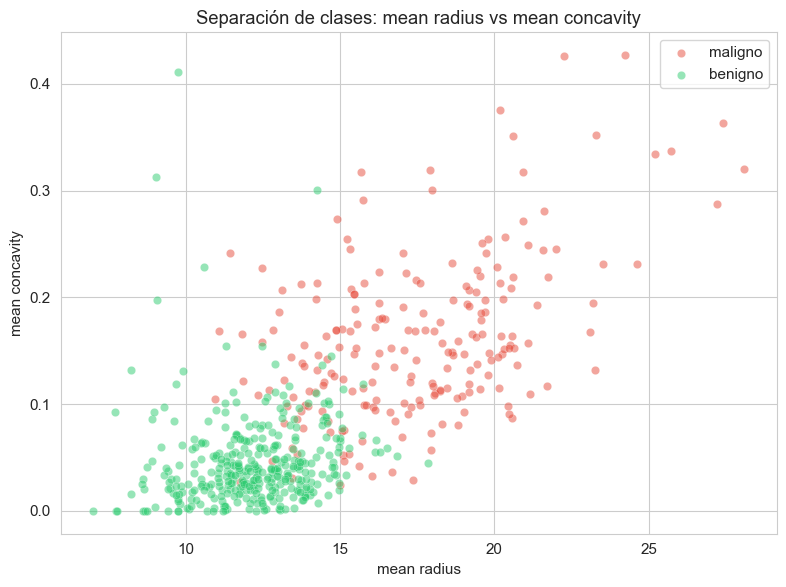

In [7]:
# 3.4  Scatter plot: 2 features más discriminativas
fig, ax = plt.subplots(figsize=(8, 6))
for label, color, name in zip([0, 1], colors, ['maligno', 'benigno']):
    mask = df['target'] == label
    ax.scatter(df.loc[mask, 'mean radius'], df.loc[mask, 'mean concavity'],
              alpha=0.5, c=color, label=name, edgecolors='w', linewidth=0.3)
ax.set_xlabel('mean radius')
ax.set_ylabel('mean concavity')
ax.set_title('Separación de clases: mean radius vs mean concavity')
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Preparación de datos

In [8]:
X = df[data.feature_names].copy()
y = df['target'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Entrenamiento: {X_train.shape[0]} muestras')
print(f'Test:          {X_test.shape[0]} muestras')
print(f'\nProporción en train: {y_train.mean():.1%} benigno')
print(f'Proporción en test:  {y_test.mean():.1%} benigno')

# Stratified K-Fold para validación cruzada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Entrenamiento: 455 muestras
Test:          114 muestras

Proporción en train: 62.6% benigno
Proporción en test:  63.2% benigno


### Funciones auxiliares para evaluación de clasificadores

In [9]:
def eval_classifier(model, X_tr, y_tr, X_te, y_te, model_name='Modelo'):
    """Evalúa un clasificador: métricas, matriz de confusión y reporte."""
    y_pred = model.predict(X_te)

    metrics = {
        'Accuracy':  accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'Recall':    recall_score(y_te, y_pred),
        'F1-Score':  f1_score(y_te, y_pred)
    }

    print(f'=== {model_name} ===')
    for k, v in metrics.items():
        print(f'  {k}: {v:.4f}')

    # Matriz de confusión
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Maligno', 'Benigno'],
                yticklabels=['Maligno', 'Benigno'])
    axes[0].set_title(f'Matriz de Confusión — {model_name}')
    axes[0].set_xlabel('Predicción')
    axes[0].set_ylabel('Real')

    # Desglose FP y FN
    tn, fp, fn, tp = cm.ravel()
    labels = ['TN\n(benigno\ncorrecto)', 'FP\n(benigno→\nmaligno)',
              'FN\n(maligno→\nbenigno)', 'TP\n(maligno\ncorrecto)']
    values = [tn, fp, fn, tp]
    bar_colors = ['#2ecc71', '#f39c12', '#e74c3c', '#3498db']
    axes[1].bar(labels, values, color=bar_colors)
    axes[1].set_title(f'Desglose — {model_name}')
    axes[1].set_ylabel('Cantidad')

    plt.tight_layout()
    plt.show()

    print(f'\n  FN (maligno no detectado): {fn}')
    print(f'  FP (benigno como maligno): {fp}')
    print(f'\nReporte completo:')
    print(classification_report(y_te, y_pred,
          target_names=['maligno', 'benigno']))

    return metrics


def plot_roc(model, X_te, y_te, model_name='Modelo', ax=None):
    """Genera la curva ROC de un modelo."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_te)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_te)
    else:
        print(f'{model_name}: no soporta probabilidades')
        return None

    fpr, tpr, _ = roc_curve(y_te, y_score)
    roc_auc = auc(fpr, tpr)

    ax.plot(fpr, tpr, linewidth=2,
            label=f'{model_name} (AUC = {roc_auc:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
    ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
    ax.set_title(f'Curva ROC — {model_name}')
    ax.legend()

    return roc_auc

---
## 5. Modelo 1 — Regresión Logística

**Fundamento:** Modelo lineal que estima P(y=1|x) mediante la función sigmoide σ(z) = 1/(1+e^(−z)). La frontera de decisión es lineal en el espacio de features. Se optimiza minimizando la Log-Loss (entropía cruzada binaria) con regularización L2 por defecto.

In [10]:
# 5.1  Pipeline con estandarización
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

# Validación cruzada estratificada
cv_lr = cross_validate(pipe_lr, X_train, y_train, cv=skf,
                       scoring=['accuracy', 'f1', 'recall'],
                       return_train_score=True)

print('Regresión Logística — Cross-Validation (5-fold)')
print(f'  Accuracy:  {cv_lr["test_accuracy"].mean():.4f} ± {cv_lr["test_accuracy"].std():.4f}')
print(f'  F1-Score:  {cv_lr["test_f1"].mean():.4f} ± {cv_lr["test_f1"].std():.4f}')
print(f'  Recall:    {cv_lr["test_recall"].mean():.4f} ± {cv_lr["test_recall"].std():.4f}')

# Entrenar modelo final
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

Regresión Logística — Cross-Validation (5-fold)
  Accuracy:  0.9780 ± 0.0098
  F1-Score:  0.9825 ± 0.0078
  Recall:    0.9860 ± 0.0131


=== Regresión Logística ===
  Accuracy: 0.9825
  Precision: 0.9861
  Recall: 0.9861
  F1-Score: 0.9861


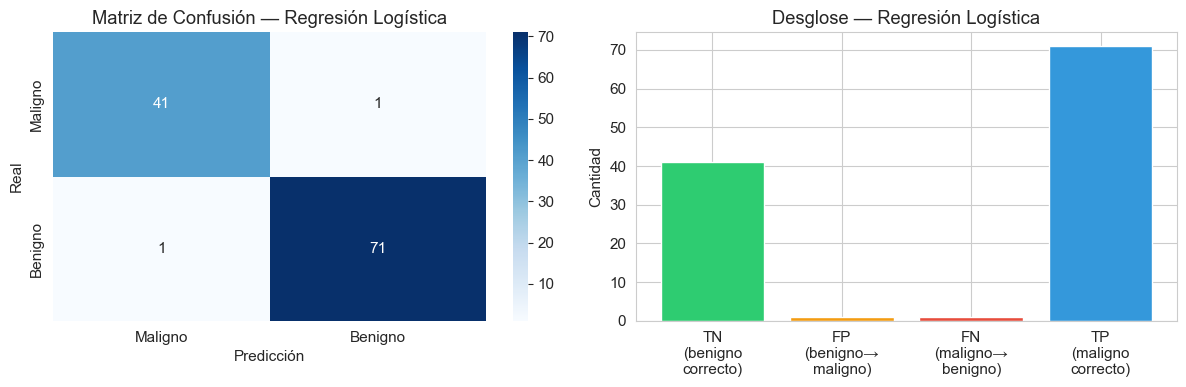


  FN (maligno no detectado): 1
  FP (benigno como maligno): 1

Reporte completo:
              precision    recall  f1-score   support

     maligno       0.98      0.98      0.98        42
     benigno       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [11]:
# 5.2  Evaluación completa
metrics_lr = eval_classifier(pipe_lr, X_train, y_train, X_test, y_test,
                             'Regresión Logística')

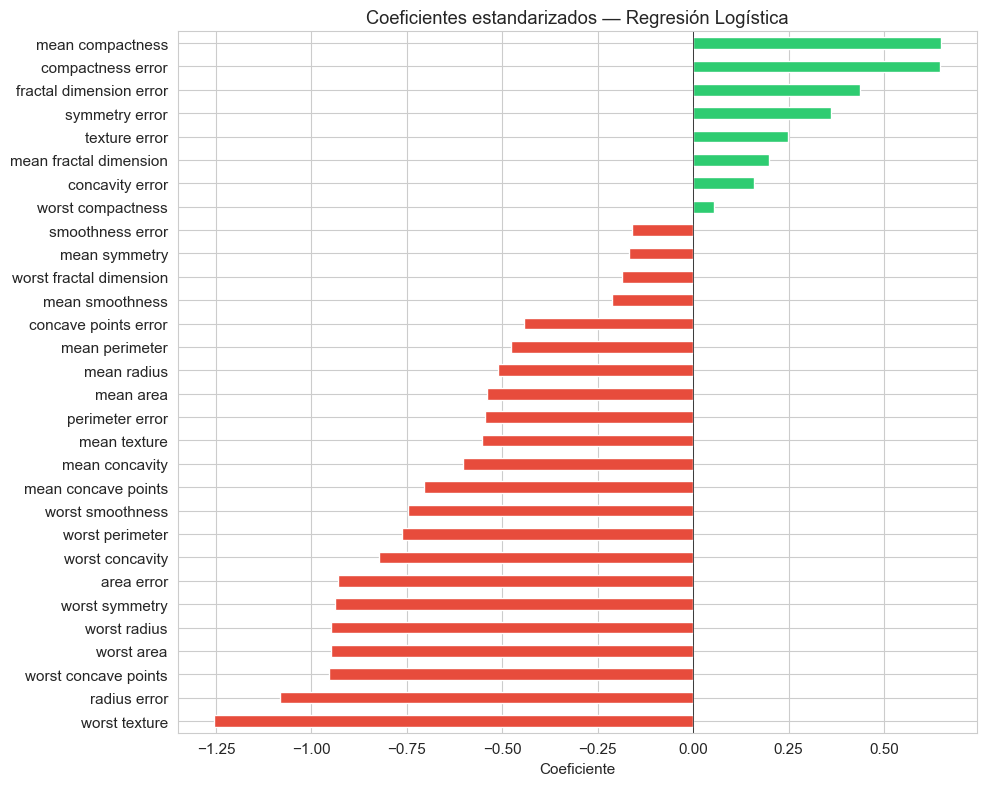

Interpretación:
  → Features que más indican MALIGNO: ['worst texture', 'radius error', 'worst concave points']
  → Features que más indican BENIGNO: ['fractal dimension error', 'compactness error', 'mean compactness']


In [12]:
# 5.3  Coeficientes estandarizados
coefs = pd.Series(
    pipe_lr.named_steps['clf'].coef_[0],
    index=data.feature_names
).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors_bar = ['#e74c3c' if c < 0 else '#2ecc71' for c in coefs]
coefs.plot(kind='barh', ax=ax, color=colors_bar)
ax.set_title('Coeficientes estandarizados — Regresión Logística')
ax.set_xlabel('Coeficiente')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print('Interpretación:')
print(f'  → Features que más indican MALIGNO: {coefs.head(3).index.tolist()}')
print(f'  → Features que más indican BENIGNO: {coefs.tail(3).index.tolist()}')

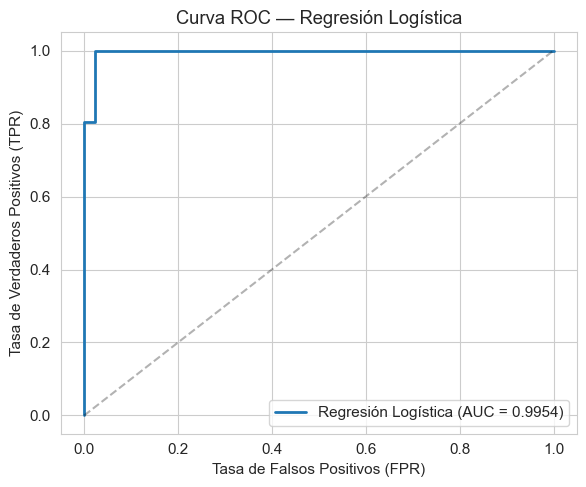

AUC: 0.9954


In [13]:
# 5.4  Curva ROC
fig, ax = plt.subplots(figsize=(6, 5))
auc_lr = plot_roc(pipe_lr, X_test, y_test, 'Regresión Logística', ax)
plt.tight_layout()
plt.show()
print(f'AUC: {auc_lr:.4f}')

---
## 6. Modelo 2 — Árbol de Decisión

**Fundamento:** CART construye particiones recursivas del espacio de features. En cada nodo selecciona la feature y el umbral que maximizan la reducción de impureza (Gini: G(t) = 1 − Σpₖ²). Las particiones son ortogonales a los ejes.

In [14]:
# 6.1  Árbol sin restricciones (para mostrar sobreajuste)
pipe_dt_full = Pipeline([
    ('clf', DecisionTreeClassifier(random_state=42))
])

cv_dt_full = cross_validate(pipe_dt_full, X_train, y_train, cv=skf,
                            scoring=['accuracy', 'f1', 'recall'],
                            return_train_score=True)

print('Árbol de Decisión (SIN restricciones) — CV 5-fold')
print(f'  Train Accuracy: {cv_dt_full["train_accuracy"].mean():.4f}')
print(f'  Test Accuracy:  {cv_dt_full["test_accuracy"].mean():.4f} ± {cv_dt_full["test_accuracy"].std():.4f}')
print(f'  Test F1-Score:  {cv_dt_full["test_f1"].mean():.4f} ± {cv_dt_full["test_f1"].std():.4f}')
print(f'\n⚠ Train accuracy ~1.0 indica sobreajuste')

Árbol de Decisión (SIN restricciones) — CV 5-fold
  Train Accuracy: 1.0000
  Test Accuracy:  0.9165 ± 0.0179
  Test F1-Score:  0.9319 ± 0.0144

⚠ Train accuracy ~1.0 indica sobreajuste


In [15]:
# 6.2  Árbol con pre-poda
pipe_dt = Pipeline([
    ('clf', DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ))
])

cv_dt = cross_validate(pipe_dt, X_train, y_train, cv=skf,
                       scoring=['accuracy', 'f1', 'recall'],
                       return_train_score=True)

print('Árbol de Decisión (con pre-poda) — CV 5-fold')
print(f'  Train Accuracy: {cv_dt["train_accuracy"].mean():.4f}')
print(f'  Test Accuracy:  {cv_dt["test_accuracy"].mean():.4f} ± {cv_dt["test_accuracy"].std():.4f}')
print(f'  Test F1-Score:  {cv_dt["test_f1"].mean():.4f} ± {cv_dt["test_f1"].std():.4f}')
print(f'  Test Recall:    {cv_dt["test_recall"].mean():.4f} ± {cv_dt["test_recall"].std():.4f}')

pipe_dt.fit(X_train, y_train)
y_pred_dt = pipe_dt.predict(X_test)

Árbol de Decisión (con pre-poda) — CV 5-fold
  Train Accuracy: 0.9747
  Test Accuracy:  0.9275 ± 0.0226
  Test F1-Score:  0.9417 ± 0.0189
  Test Recall:    0.9368 ± 0.0325


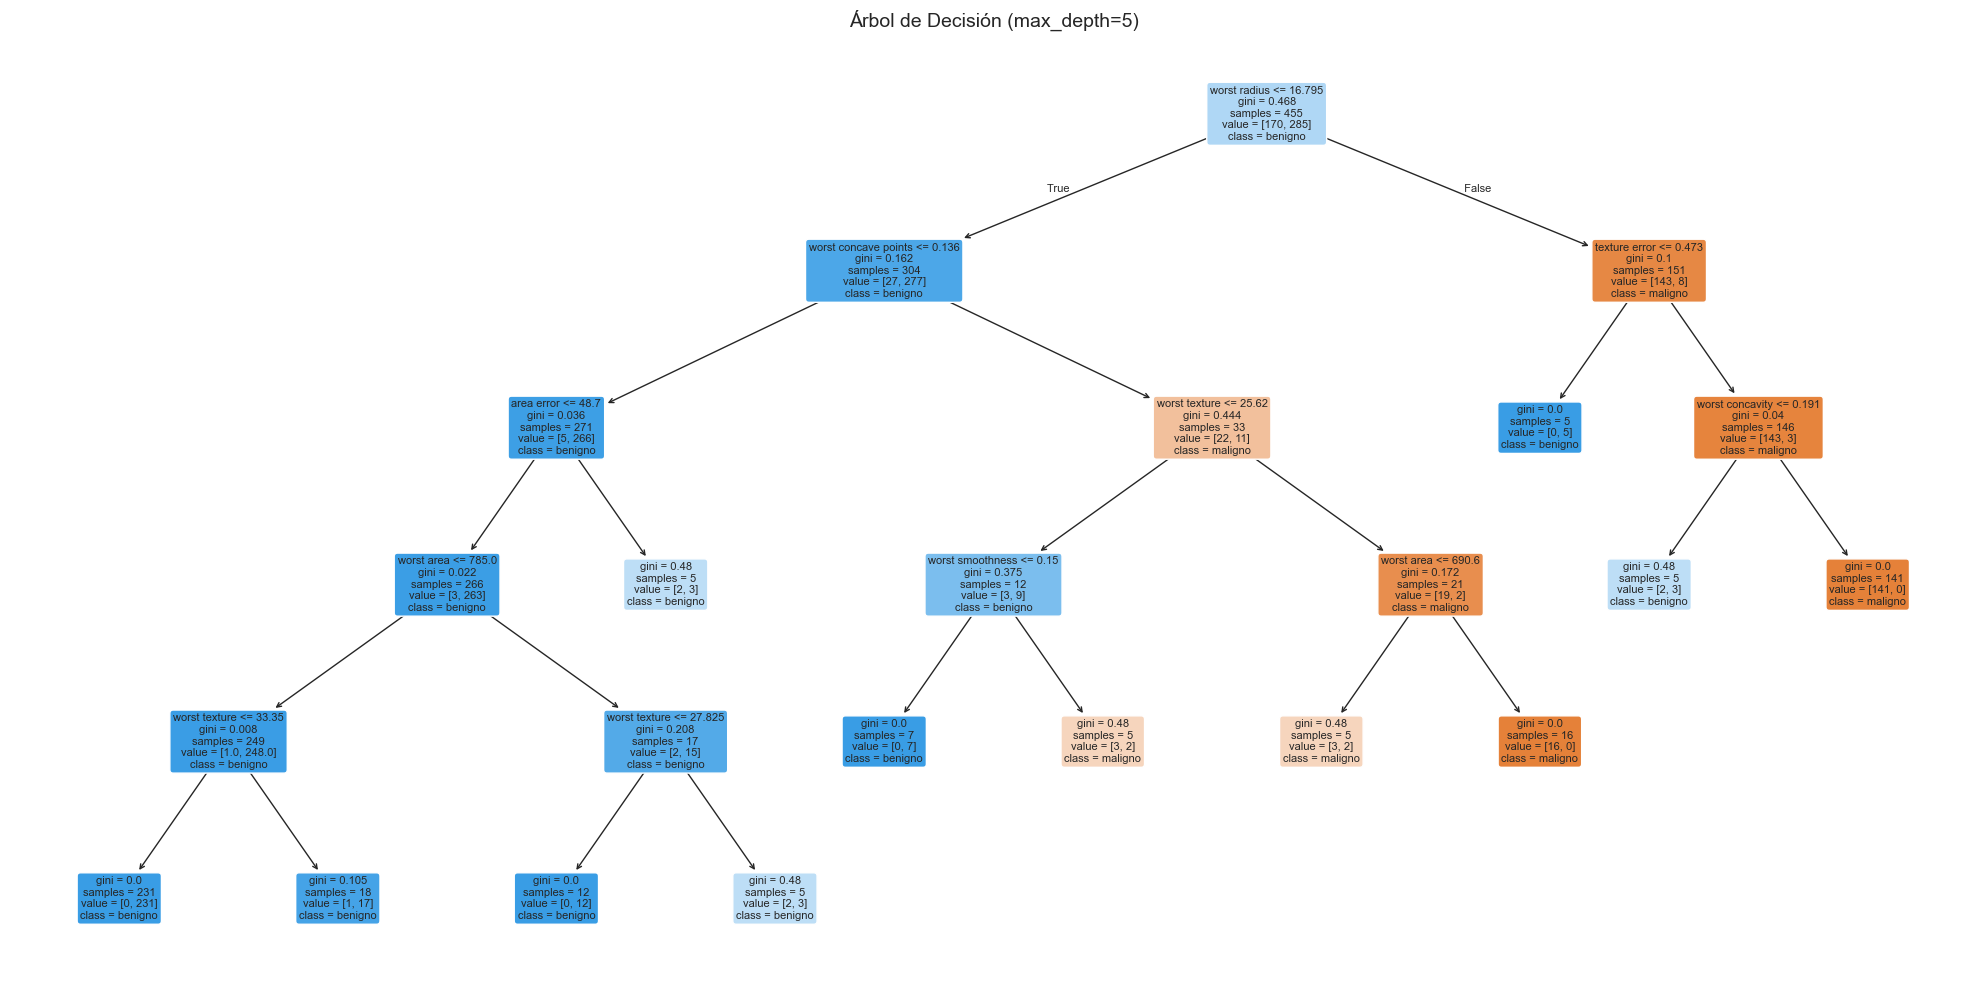

In [16]:
# 6.3  Visualización del árbol podado
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(pipe_dt.named_steps['clf'],
          feature_names=data.feature_names,
          class_names=['maligno', 'benigno'],
          filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title('Árbol de Decisión (max_depth=5)', fontsize=14)
plt.tight_layout()
plt.show()

=== Árbol de Decisión ===
  Accuracy: 0.9211
  Precision: 0.9437
  Recall: 0.9306
  F1-Score: 0.9371


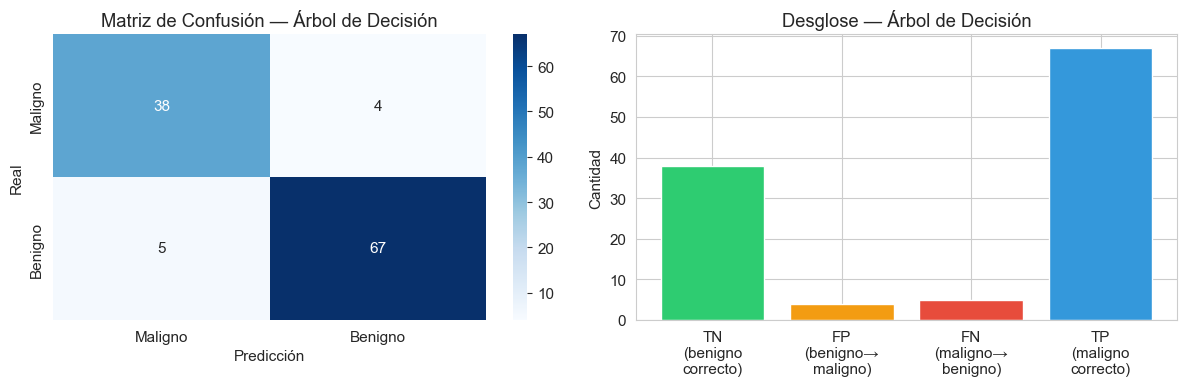


  FN (maligno no detectado): 5
  FP (benigno como maligno): 4

Reporte completo:
              precision    recall  f1-score   support

     maligno       0.88      0.90      0.89        42
     benigno       0.94      0.93      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



In [17]:
# 6.4  Evaluación completa
metrics_dt = eval_classifier(pipe_dt, X_train, y_train, X_test, y_test,
                             'Árbol de Decisión')

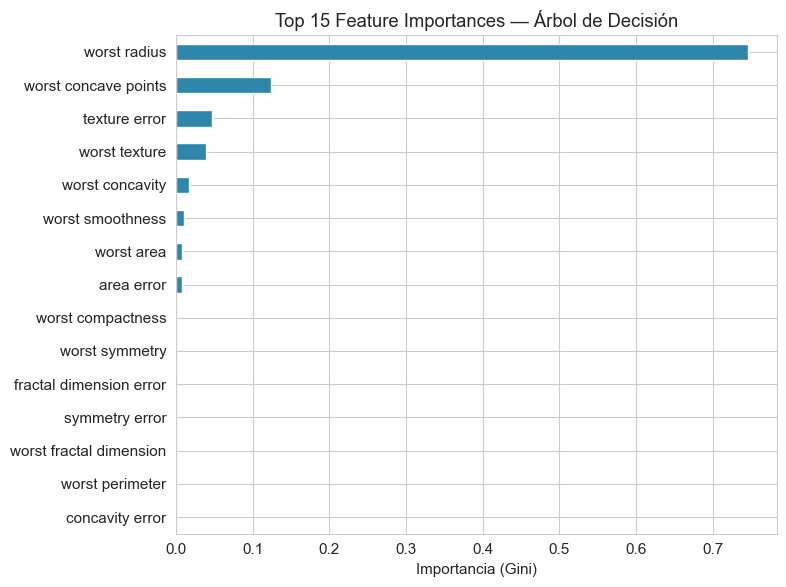

In [18]:
# 6.5  Importancia de features
importances = pd.Series(
    pipe_dt.named_steps['clf'].feature_importances_,
    index=data.feature_names
).sort_values(ascending=True)

# Top 15
top_imp = importances.tail(15)
fig, ax = plt.subplots(figsize=(8, 6))
top_imp.plot(kind='barh', ax=ax, color='#2E86AB')
ax.set_title('Top 15 Feature Importances — Árbol de Decisión')
ax.set_xlabel('Importancia (Gini)')
plt.tight_layout()
plt.show()

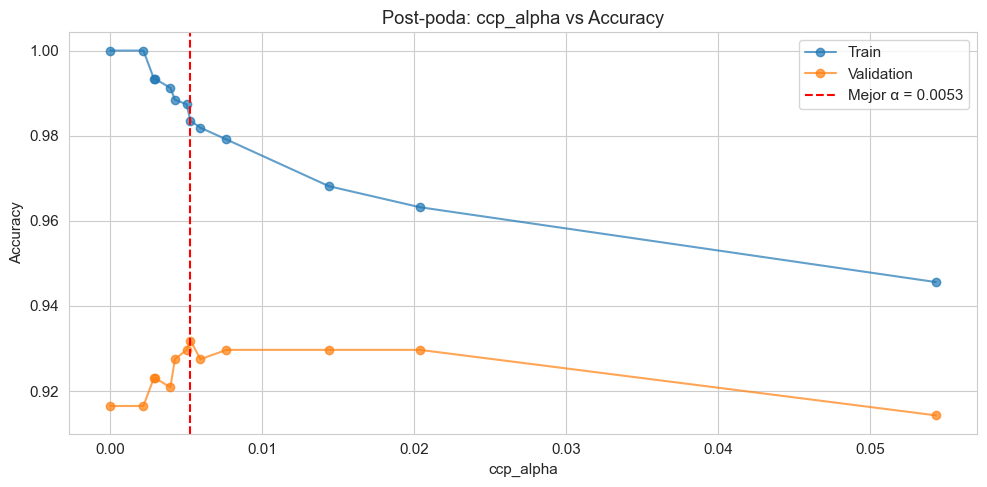

Mejor ccp_alpha: 0.005275


In [19]:
# 6.6  Post-poda con ccp_alpha
path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_train, y_train)
alphas = path.ccp_alphas[:-1]  # excluir el último (árbol trivial)

train_scores, test_scores = [], []
for alpha in alphas:
    dt_temp = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    cv_temp = cross_validate(dt_temp, X_train, y_train, cv=skf,
                             scoring='accuracy', return_train_score=True)
    train_scores.append(cv_temp['train_score'].mean())
    test_scores.append(cv_temp['test_score'].mean())

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(alphas, train_scores, 'o-', label='Train', alpha=0.7)
ax.plot(alphas, test_scores, 'o-', label='Validation', alpha=0.7)
best_idx = np.argmax(test_scores)
ax.axvline(x=alphas[best_idx], color='red', linestyle='--',
           label=f'Mejor α = {alphas[best_idx]:.4f}')
ax.set_xlabel('ccp_alpha')
ax.set_ylabel('Accuracy')
ax.set_title('Post-poda: ccp_alpha vs Accuracy')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Mejor ccp_alpha: {alphas[best_idx]:.6f}')

---
## 7. Modelo 3 — Support Vector Machine (SVM)

**Fundamento:** SVM busca el hiperplano de máximo margen γ = 2/‖w‖ que separa las clases. Con margen suave, permite violaciones controladas: min ½‖w‖² + C·Σξᵢ. El kernel trick transforma el espacio para manejar no linealidad.

In [20]:
# 7.1  Pipeline SVM con kernel RBF
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel='rbf', C=1.0, probability=True, random_state=42))
])

cv_svm = cross_validate(pipe_svm, X_train, y_train, cv=skf,
                        scoring=['accuracy', 'f1', 'recall'],
                        return_train_score=True)

print('SVM (RBF, C=1.0) — CV 5-fold')
print(f'  Accuracy:  {cv_svm["test_accuracy"].mean():.4f} ± {cv_svm["test_accuracy"].std():.4f}')
print(f'  F1-Score:  {cv_svm["test_f1"].mean():.4f} ± {cv_svm["test_f1"].std():.4f}')
print(f'  Recall:    {cv_svm["test_recall"].mean():.4f} ± {cv_svm["test_recall"].std():.4f}')

pipe_svm.fit(X_train, y_train)
y_pred_svm = pipe_svm.predict(X_test)

SVM (RBF, C=1.0) — CV 5-fold
  Accuracy:  0.9692 ± 0.0146
  F1-Score:  0.9756 ± 0.0113
  Recall:    0.9789 ± 0.0131


=== SVM (RBF) ===
  Accuracy: 0.9825
  Precision: 0.9861
  Recall: 0.9861
  F1-Score: 0.9861


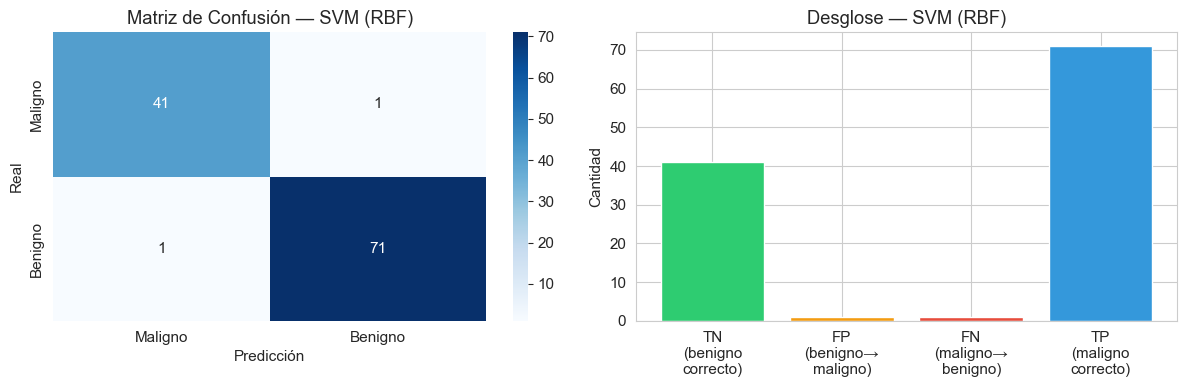


  FN (maligno no detectado): 1
  FP (benigno como maligno): 1

Reporte completo:
              precision    recall  f1-score   support

     maligno       0.98      0.98      0.98        42
     benigno       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [21]:
# 7.2  Evaluación completa
metrics_svm = eval_classifier(pipe_svm, X_train, y_train, X_test, y_test, 'SVM (RBF)')

  Kernel linear  : Accuracy = 0.9648
  Kernel rbf     : Accuracy = 0.9692
  Kernel poly    : Accuracy = 0.8967


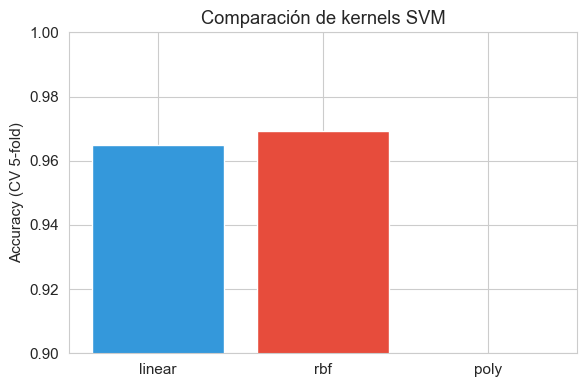

In [22]:
# 7.3  Comparación de kernels
kernels = ['linear', 'rbf', 'poly']
kernel_results = {}

for k in kernels:
    pipe_k = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel=k, C=1.0, probability=True, random_state=42))
    ])
    cv_k = cross_validate(pipe_k, X_train, y_train, cv=skf,
                          scoring='accuracy')
    kernel_results[k] = cv_k['test_score'].mean()
    print(f'  Kernel {k:8s}: Accuracy = {kernel_results[k]:.4f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(kernel_results.keys(), kernel_results.values(), color=['#3498db', '#e74c3c', '#2ecc71'])
ax.set_ylabel('Accuracy (CV 5-fold)')
ax.set_title('Comparación de kernels SVM')
ax.set_ylim(0.9, 1.0)
plt.tight_layout()
plt.show()

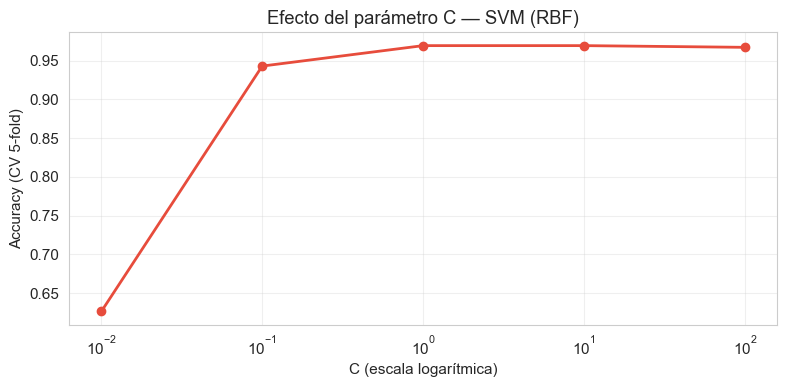


Interpretación:
  C bajo → margen amplio, más errores permitidos (mayor sesgo)
  C alto → margen estrecho, menos errores permitidos (mayor varianza)


In [23]:
# 7.4  Efecto del parámetro C
C_values = [0.01, 0.1, 1, 10, 100]
c_scores = []

for c in C_values:
    pipe_c = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', C=c, random_state=42))
    ])
    cv_c = cross_validate(pipe_c, X_train, y_train, cv=skf, scoring='accuracy')
    c_scores.append(cv_c['test_score'].mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(C_values, c_scores, 'o-', color='#e74c3c', linewidth=2)
ax.set_xlabel('C (escala logarítmica)')
ax.set_ylabel('Accuracy (CV 5-fold)')
ax.set_title('Efecto del parámetro C — SVM (RBF)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\nInterpretación:')
print('  C bajo → margen amplio, más errores permitidos (mayor sesgo)')
print('  C alto → margen estrecho, menos errores permitidos (mayor varianza)')

---
## 8. Modelo 4 — K-Nearest Neighbors (KNN)

**Fundamento:** Algoritmo de aprendizaje basado en instancias (lazy learning). No construye un modelo explícito; clasifica por voto mayoritario de los K vecinos más cercanos según distancia Euclidiana (por defecto). La regla empírica sugiere K ≈ √n.

In [24]:
# 8.1  Pipeline KNN
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier(n_neighbors=5))
])

cv_knn = cross_validate(pipe_knn, X_train, y_train, cv=skf,
                        scoring=['accuracy', 'f1', 'recall'],
                        return_train_score=True)

print('KNN (K=5) — CV 5-fold')
print(f'  Accuracy:  {cv_knn["test_accuracy"].mean():.4f} ± {cv_knn["test_accuracy"].std():.4f}')
print(f'  F1-Score:  {cv_knn["test_f1"].mean():.4f} ± {cv_knn["test_f1"].std():.4f}')
print(f'  Recall:    {cv_knn["test_recall"].mean():.4f} ± {cv_knn["test_recall"].std():.4f}')

pipe_knn.fit(X_train, y_train)
y_pred_knn = pipe_knn.predict(X_test)

KNN (K=5) — CV 5-fold
  Accuracy:  0.9626 ± 0.0112
  F1-Score:  0.9705 ± 0.0091
  Recall:    0.9825 ± 0.0192


=== KNN (K=5) ===
  Accuracy: 0.9561
  Precision: 0.9589
  Recall: 0.9722
  F1-Score: 0.9655


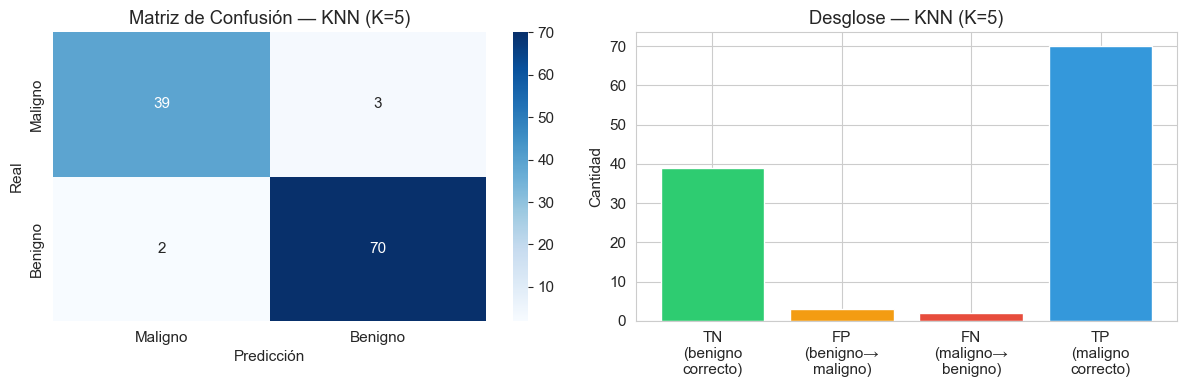


  FN (maligno no detectado): 2
  FP (benigno como maligno): 3

Reporte completo:
              precision    recall  f1-score   support

     maligno       0.95      0.93      0.94        42
     benigno       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [25]:
# 8.2  Evaluación completa
metrics_knn = eval_classifier(pipe_knn, X_train, y_train, X_test, y_test, 'KNN (K=5)')

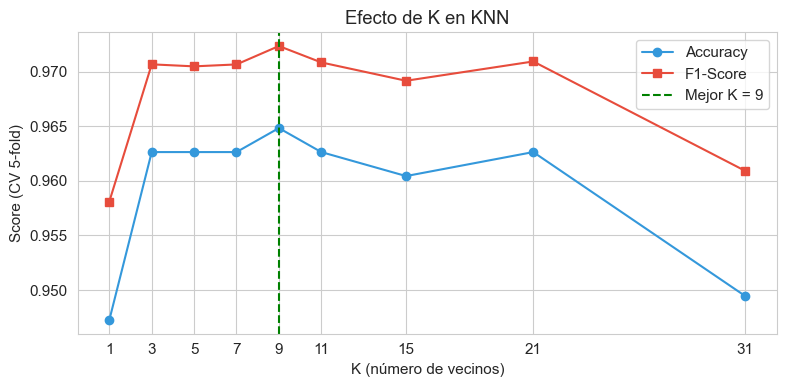

Mejor K por F1: 9
K empírico (√455): 21


In [26]:
# 8.3  Búsqueda del K óptimo
k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31]
k_scores_acc = []
k_scores_f1 = []

for k in k_values:
    pipe_k = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=k))
    ])
    cv_k = cross_validate(pipe_k, X_train, y_train, cv=skf,
                          scoring=['accuracy', 'f1'])
    k_scores_acc.append(cv_k['test_accuracy'].mean())
    k_scores_f1.append(cv_k['test_f1'].mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_values, k_scores_acc, 'o-', label='Accuracy', color='#3498db')
ax.plot(k_values, k_scores_f1, 's-', label='F1-Score', color='#e74c3c')
best_k = k_values[np.argmax(k_scores_f1)]
ax.axvline(x=best_k, color='green', linestyle='--', label=f'Mejor K = {best_k}')
ax.set_xlabel('K (número de vecinos)')
ax.set_ylabel('Score (CV 5-fold)')
ax.set_title('Efecto de K en KNN')
ax.legend()
ax.set_xticks(k_values)
plt.tight_layout()
plt.show()

print(f'Mejor K por F1: {best_k}')
print(f'K empírico (√{len(X_train)}): {int(np.sqrt(len(X_train)))}')

In [27]:
# 8.4  Comparación de métricas de distancia
distances = ['euclidean', 'manhattan', 'minkowski']
dist_results = {}

for d in distances:
    p_val = 3 if d == 'minkowski' else 2
    pipe_d = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=5, metric=d, p=p_val))
    ])
    cv_d = cross_validate(pipe_d, X_train, y_train, cv=skf, scoring='f1')
    dist_results[d] = cv_d['test_score'].mean()
    label = f'{d} (p={p_val})' if d == 'minkowski' else d
    print(f'  Distancia {label:20s}: F1 = {dist_results[d]:.4f}')

  Distancia euclidean           : F1 = 0.9705
  Distancia manhattan           : F1 = 0.9705
  Distancia minkowski (p=3)     : F1 = 0.9658


---
## 9. Comparación final de modelos

In [28]:
# 9.1  Tabla resumen de métricas
all_models = {
    'Regresión Logística': pipe_lr,
    'Árbol de Decisión': pipe_dt,
    'SVM (RBF)': pipe_svm,
    'KNN (K=5)': pipe_knn
}

all_metrics = {}
for name, model in all_models.items():
    y_pred = model.predict(X_test)
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc_val = auc(fpr, tpr)
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_test)
        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_auc_val = auc(fpr, tpr)
    else:
        roc_auc_val = None

    all_metrics[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC': roc_auc_val
    }

metrics_df = pd.DataFrame(all_metrics).T.round(4)
print('=== Tabla comparativa de métricas (Test Set) ===')
metrics_df

=== Tabla comparativa de métricas (Test Set) ===


,Accuracy,Precision,Recall,F1-Score,AUC
Regresión Logística,0.9825,0.9861,0.9861,0.9861,0.9954
Árbol de Decisión,0.9211,0.9437,0.9306,0.9371,0.9368
SVM (RBF),0.9825,0.9861,0.9861,0.9861,0.9950
KNN (K=5),0.9561,0.9589,0.9722,0.9655,0.9788


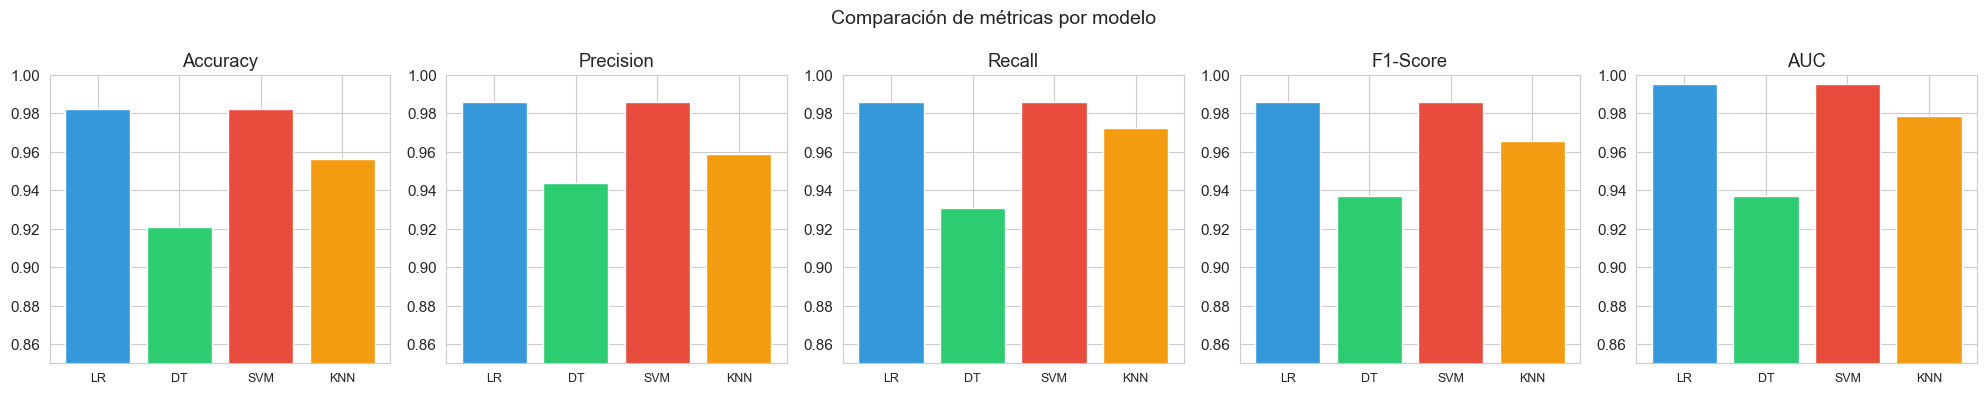

In [29]:
# 9.2  Gráfico de barras comparativo
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
colors_models = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for i, metric in enumerate(metric_names):
    values = [all_metrics[m][metric] for m in all_metrics]
    axes[i].bar(range(len(values)), values, color=colors_models)
    axes[i].set_title(metric)
    axes[i].set_ylim(0.85, 1.0)
    axes[i].set_xticks(range(len(values)))
    axes[i].set_xticklabels(['LR', 'DT', 'SVM', 'KNN'], fontsize=9)

plt.suptitle('Comparación de métricas por modelo', fontsize=14)
plt.tight_layout()
plt.show()

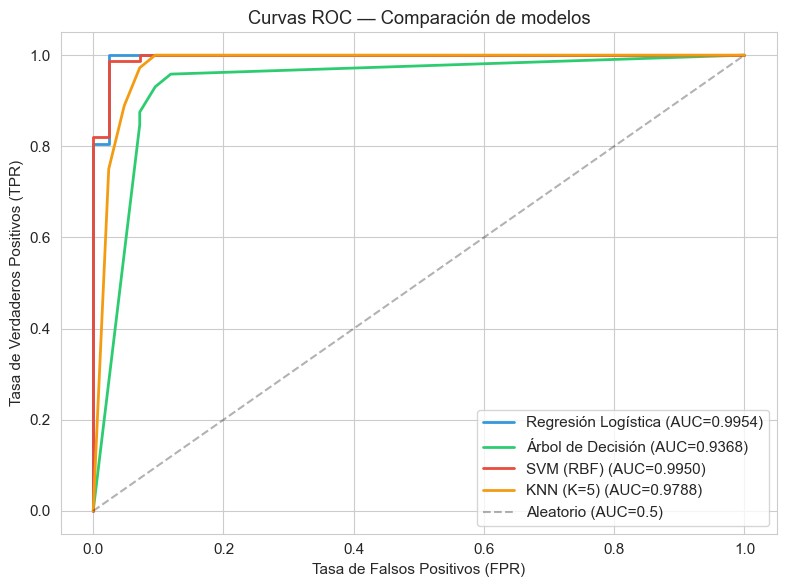

In [30]:
# 9.3  Curvas ROC superpuestas
fig, ax = plt.subplots(figsize=(8, 6))

for (name, model), color in zip(all_models.items(), colors_models):
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_prob = model.decision_function(X_test)
    else:
        continue
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, color=color,
            label=f'{name} (AUC={roc_auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Aleatorio (AUC=0.5)')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax.set_title('Curvas ROC — Comparación de modelos')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [31]:
# 9.4  Matriz de selección
selection_matrix = pd.DataFrame({
    'Modelo': ['Reg. Logística', 'Árbol de Decisión', 'SVM (RBF)', 'KNN'],
    'Precisión predictiva': ['★★★★☆', '★★★☆☆', '★★★★★', '★★★★☆'],
    'Velocidad (train+pred)': ['★★★★★', '★★★★☆', '★★★☆☆', '★★★★★'],
    'Interpretabilidad': ['★★★★☆', '★★★★★', '★★☆☆☆', '★★★☆☆'],
    'Escalabilidad': ['★★★★★', '★★★★☆', '★★☆☆☆', '★★☆☆☆'],
    'Robustez a outliers': ['★★★☆☆', '★★★★☆', '★★★★☆', '★★☆☆☆']
}).set_index('Modelo')

print('=== Matriz de Selección de Modelos ===')
selection_matrix

=== Matriz de Selección de Modelos ===


,Precisión predictiva,Velocidad (train+pred),Interpretabilidad,Escalabilidad,Robustez a outliers
Modelo,,,,,
Reg. Logística,★★★★☆,★★★★★,★★★★☆,★★★★★,★★★☆☆
Árbol de Decisión,★★★☆☆,★★★★☆,★★★★★,★★★★☆,★★★★☆
SVM (RBF),★★★★★,★★★☆☆,★★☆☆☆,★★☆☆☆,★★★★☆
KNN,★★★★☆,★★★★★,★★★☆☆,★★☆☆☆,★★☆☆☆


---
## 10. Resumen comparativo

| Modelo | Fortalezas | Limitaciones | ¿Cuándo usarlo? |
|---|---|---|---|
| **Reg. Logística** | Interpretable, probabilístico, rápido | Asume linealidad en log-odds | Clasificación binaria con necesidad de interpretabilidad |
| **Árbol de Decisión** | Explicable, maneja tipos mixtos | Propenso a sobreajuste sin poda | Reglas de negocio, explicabilidad ante stakeholders |
| **SVM** | Efectivo en alta dimensión, robusto al ruido | Lento con muchos datos, difícil de interpretar | Datasets de dimensión media-alta, márgenes claros |
| **KNN** | Simple, no paramétrico, flexible | Lento en predicción, maldición de la dimensionalidad | Datasets pequeños-medianos con features normalizadas |

**Criterio de selección final:** En este dataset médico, **Recall** es la métrica prioritaria (minimizar falsos negativos). El modelo con mejor Recall en test es el candidato preferido para despliegue.

Optimización con GridSearchCV

In [32]:

print('OPTIMIZACIÓN CON GRIDSEARCHCV')


from sklearn.model_selection import GridSearchCV

# 1. Optimización de Regresión Logística
print('\n Buscando mejores parámetros para Regresión Logística...')
param_grid_lr = {'clf__C': [0.01, 0.1, 1, 10, 100]}
grid_lr = GridSearchCV(
    Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
    param_grid_lr, cv=5, scoring='f1', n_jobs=-1
)
grid_lr.fit(X_train, y_train)
print(f' Mejor LR: C = {grid_lr.best_params_["clf__C"]}, F1-Score = {grid_lr.best_score_:.4f}')

# 2. Optimización de Árbol de Decisión
print('\n Buscando mejores parámetros para Árbol de Decisión...')
param_grid_dt = {'clf__max_depth': [3, 5, 7, 10], 'clf__min_samples_leaf': [1, 5, 10]}
grid_dt = GridSearchCV(
    Pipeline([('clf', DecisionTreeClassifier(random_state=42))]),
    param_grid_dt, cv=5, scoring='f1', n_jobs=-1
)
grid_dt.fit(X_train, y_train)
print(f' Mejor DT: {grid_dt.best_params_}, F1-Score = {grid_dt.best_score_:.4f}')



OPTIMIZACIÓN CON GRIDSEARCHCV

 Buscando mejores parámetros para Regresión Logística...
 Mejor LR: C = 0.1, F1-Score = 0.9845

 Buscando mejores parámetros para Árbol de Decisión...
 Mejor DT: {'clf__max_depth': 5, 'clf__min_samples_leaf': 5}, F1-Score = 0.9500


 Manejo de Desbalance (class_weight y SMOTE)

In [33]:

print('MANEJO DE DESBALANCE (class_weight y SMOTE)')


# A) Usando class_weight='balanced'
print('\n1️ Probando con class_weight="balanced"...')
lr_balanced = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])
lr_balanced.fit(X_train, y_train)
y_pred_bal = lr_balanced.predict(X_test)

# Nota: en este dataset, 0 = maligno. Usamos pos_label=0 para medir el recall de la clase maligna.
recall_bal = recall_score(y_test, y_pred_bal, pos_label=0)
print(f'   → Recall (Maligno) con class_weight: {recall_bal:.4f}')

# B) Usando SMOTE (Sintetic Minority Over-sampling Technique)
print('\n2️ Probando con SMOTE...')
try:
    from imblearn.over_sampling import SMOTE

    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

    print(f'   • Tamaño de X_train original: {X_train.shape[0]}')
    print(f'   • Tamaño de X_train con SMOTE:  {X_train_smote.shape[0]} (¡Clases balanceadas!)')

    lr_smote = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ])
    lr_smote.fit(X_train_smote, y_train_smote)
    y_pred_smote = lr_smote.predict(X_test)

    recall_smote = recall_score(y_test, y_pred_smote, pos_label=0)
    print(f'   → Recall (Maligno) con SMOTE: {recall_smote:.4f}')

except ImportError:
    print('   La librería "imbalanced-learn" no está instalada.')
    print('   Solución: Ejecuta esta celda: !pip install imbalanced-learn')

MANEJO DE DESBALANCE (class_weight y SMOTE)

1️ Probando con class_weight="balanced"...
   → Recall (Maligno) con class_weight: 0.9762

2️ Probando con SMOTE...
   • Tamaño de X_train original: 455
   • Tamaño de X_train con SMOTE:  570 (¡Clases balanceadas!)
   → Recall (Maligno) con SMOTE: 0.9762


---
## 11. Ejercicios propuestos

### Ejercicio 1 — Optimización con GridSearchCV
Para cada modelo, realice una búsqueda exhaustiva de hiperparámetros con `GridSearchCV(cv=5, scoring='f1')`. Parámetros sugeridos:
- **LogisticRegression:** C=[0.01, 0.1, 1, 10, 100]
- **DecisionTree:** max_depth=[3,5,7,10,None], min_samples_leaf=[1,5,10]
- **SVM:** C=[0.1,1,10], gamma=[0.001,0.01,0.1]
- **KNN:** n_neighbors=[3,5,9,15,21], weights=['uniform','distance']

Compare los mejores modelos optimizados.

### Ejercicio 2 — Manejo de desbalance con class_weight y SMOTE
Entrene los 4 modelos con `class_weight='balanced'`. Compare Recall de la clase maligna con y sin balanceo. Además, aplique SMOTE:
```python
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)
```

### Ejercicio 3 — Dataset propio
Seleccione un dataset de clasificación de Kaggle/UCI (mín. 500 registros, 5 features). Aplique los 4 modelos + al menos 1 adicional (Random Forest, Gradient Boosting o Naive Bayes). Documente métricas, curvas ROC, matriz de selección y justificación del mejor modelo.

---
## 12. Resolución de los ejercicios propuestos

- **Ejercicios 1 y 2:** se resuelven con el dataset **Breast Cancer Wisconsin** de las secciones anteriores (mismas variables `X_train`, `X_test`, `y_train`, `y_test`; clase maligna = 0, benigna = 1).
- **Ejercicio 3:** se resuelve con un dataset propio de Kaggle/UCI: **Diabetes de Pima Indians** (`diabetes.csv`).

---
### Ejercicio 1 — Optimización con GridSearchCV (Breast Cancer)
`GridSearchCV(cv=5, scoring='f1')` para los 4 modelos con las grillas sugeridas. Se compara cada modelo optimizado contra su versión con hiperparámetros por defecto en el conjunto de test. Además del F1 (clase benigna, que es la que usa `scoring='f1'`) se reporta el **Recall de la clase maligna**, que es la métrica crítica en este problema médico.

In [34]:
from sklearn.model_selection import GridSearchCV

def pipe(clf, escalar=True):
    return Pipeline(([('scaler', StandardScaler())] if escalar else []) + [('clf', clf)])

def evaluar(model, X_te, y_te):
    """Métricas en test. Positivo = benigno (1), como en scoring='f1'; además Recall de la clase MALIGNA (0)."""
    y_pred = model.predict(X_te)
    score = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, score)
    return {'Accuracy': accuracy_score(y_te, y_pred),
            'F1': f1_score(y_te, y_pred),
            'Recall maligno': recall_score(y_te, y_pred, pos_label=0),
            'AUC': auc(fpr, tpr)}, fpr, tpr

definiciones = {
    'Regresión Logística': (lambda: pipe(LogisticRegression(max_iter=1000, random_state=42)),
                            {'clf__C': [0.01, 0.1, 1, 10, 100]}),
    'Árbol de Decisión':   (lambda: pipe(DecisionTreeClassifier(random_state=42), escalar=False),
                            {'clf__max_depth': [3, 5, 7, 10, None], 'clf__min_samples_leaf': [1, 5, 10]}),
    'SVM (RBF)':           (lambda: pipe(SVC(kernel='rbf', probability=True, random_state=42)),
                            {'clf__C': [0.1, 1, 10], 'clf__gamma': [0.001, 0.01, 0.1]}),
    'KNN':                 (lambda: pipe(KNeighborsClassifier()),
                            {'clf__n_neighbors': [3, 5, 9, 15, 21], 'clf__weights': ['uniform', 'distance']}),
}

filas, roc_opt = [], {}
for nombre, (fabrica, grilla) in definiciones.items():
    m_base, _, _ = evaluar(fabrica().fit(X_train, y_train), X_test, y_test)
    gs = GridSearchCV(fabrica(), grilla, cv=5, scoring='f1', n_jobs=-1).fit(X_train, y_train)
    m_opt, fpr, tpr = evaluar(gs.best_estimator_, X_test, y_test)
    roc_opt[nombre] = (fpr, tpr, m_opt['AUC'])
    filas.append({'Modelo': nombre,
                  'Mejores hiperparámetros': {k.replace('clf__', ''): v for k, v in gs.best_params_.items()},
                  'F1 CV': round(gs.best_score_, 4),
                  'F1 test (base)': round(m_base['F1'], 4),
                  'F1 test (optimizado)': round(m_opt['F1'], 4),
                  'Recall maligno': round(m_opt['Recall maligno'], 4),
                  'Accuracy': round(m_opt['Accuracy'], 4),
                  'AUC': round(m_opt['AUC'], 4)})

res_grid = pd.DataFrame(filas).set_index('Modelo')
pd.set_option('display.max_colwidth', None)
display(res_grid)

,Mejores hiperparámetros,F1 CV,F1 test (base),F1 test (optimizado),Recall maligno,Accuracy,AUC
Modelo,,,,,,,
Regresión Logística,{'C': 0.1},0.9845,0.9861,0.9793,0.9524,0.9737,0.9957
Árbol de Decisión,"{'max_depth': 5, 'min_samples_leaf': 5}",0.9500,0.9286,0.9371,0.9048,0.9211,0.9368
SVM (RBF),"{'C': 10, 'gamma': 0.01}",0.9844,0.9861,0.9861,0.9762,0.9825,0.9977
KNN,"{'n_neighbors': 3, 'weights': 'uniform'}",0.9759,0.9655,0.9863,0.9524,0.9825,0.9835


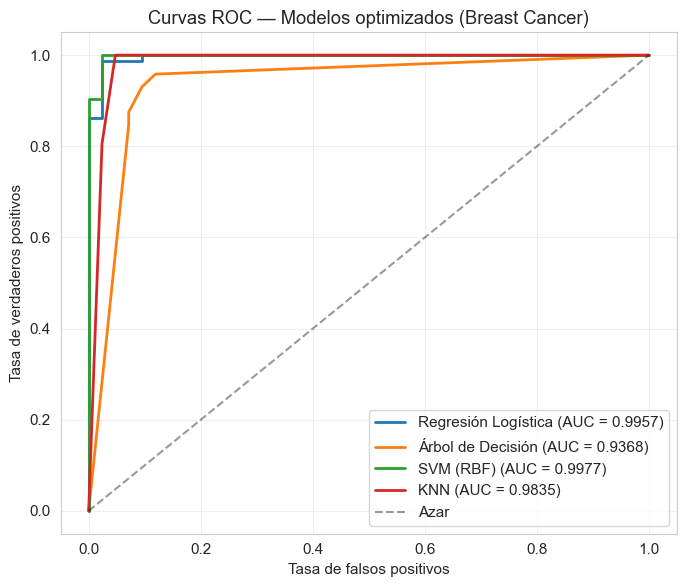

In [35]:
# Curvas ROC de los modelos optimizados
fig, ax = plt.subplots(figsize=(7, 6))
for nombre, (fpr, tpr, a) in roc_opt.items():
    ax.plot(fpr, tpr, linewidth=2, label=f'{nombre} (AUC = {a:.4f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Azar')
ax.set_xlabel('Tasa de falsos positivos'); ax.set_ylabel('Tasa de verdaderos positivos')
ax.set_title('Curvas ROC — Modelos optimizados (Breast Cancer)')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Análisis del Ejercicio 1.**

- **Mejores hiperparámetros:** Regresión Logística `C=0.1`; Árbol `max_depth=5, min_samples_leaf=5`; SVM `C=10, gamma=0.01`; KNN `n_neighbors=3, weights='uniform'`.
- **Validación cruzada:** Regresión Logística (0.9845) y SVM (0.9844) empatan como mejores; KNN queda en 0.976 y el Árbol de Decisión es claramente el más bajo (0.950).
- **Efecto de optimizar (F1 en test, base → optimizado):**
  - *KNN* es el que más mejora: 0.966 → 0.986 (con `k=3` en lugar de `k=5`).
  - *Árbol de Decisión* mejora un poco: 0.929 → 0.937, pero sigue siendo el peor modelo.
  - *SVM* se mantiene (0.986) y *Regresión Logística* baja levemente (0.986 → 0.979), lo que corresponde a un solo paciente más mal clasificado en test: la mejor combinación por CV no siempre mejora el test.
- **Comparación final:** el **SVM optimizado** es el mejor modelo global: Accuracy 0.9825, F1 0.986, mayor Recall de la clase maligna (0.976, solo 1 maligno no detectado de 42) y mayor AUC (0.998). KNN optimizado lo iguala en F1 y Accuracy pero con menor Recall maligno (0.952) y AUC (0.984). El Árbol tiene el peor Recall maligno (0.905, 4 falsos negativos).
- **Conclusión:** en un dataset casi linealmente separable como este, los modelos lineales/kernel ya rinden muy bien por defecto y la optimización aporta ganancias pequeñas; el mayor beneficio es para KNN y el árbol. Con solo 114 muestras de test, diferencias de 1 paciente no son concluyentes.

---
### Ejercicio 2 — Manejo de desbalance con `class_weight` y SMOTE (Breast Cancer)
En el conjunto de entrenamiento hay 285 benignos y 170 malignos (≈ 1.7 : 1). Se compara el **Recall de la clase maligna** (`pos_label=0`) sin balanceo, con `class_weight='balanced'` y con SMOTE (aplicado solo al train).

**Nota:** `KNeighborsClassifier` **no tiene** el parámetro `class_weight`, por lo que para KNN solo se compara sin balanceo vs SMOTE.

In [36]:
import sys, subprocess
try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'imbalanced-learn'])
    from imblearn.over_sampling import SMOTE

def modelos(balanced=False):
    cw = 'balanced' if balanced else None
    d = {'Regresión Logística': pipe(LogisticRegression(max_iter=1000, class_weight=cw, random_state=42)),
         'Árbol de Decisión':   pipe(DecisionTreeClassifier(max_depth=5, min_samples_split=10, min_samples_leaf=5,
                                                            class_weight=cw, random_state=42), escalar=False),
         'SVM (RBF)':           pipe(SVC(kernel='rbf', C=1.0, class_weight=cw, probability=True, random_state=42))}
    if not balanced:
        d['KNN (K=5)'] = pipe(KNeighborsClassifier(n_neighbors=5))   # KNN no tiene el parámetro class_weight
    return d

# SMOTE: solo sobre el conjunto de entrenamiento (nunca sobre el test)
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)
print(f'Train original : {len(y_train)} muestras -> {y_train.value_counts().to_dict()}  (0 = maligno, 1 = benigno)')
print(f'Train con SMOTE: {len(y_res)} muestras -> {y_res.value_counts().to_dict()}')

def metr_maligno(model):
    p = model.predict(X_test)
    fn = int(((y_test == 0) & (p == 1)).sum())          # maligno clasificado como benigno
    return (recall_score(y_test, p, pos_label=0), precision_score(y_test, p, pos_label=0),
            f1_score(y_test, p, pos_label=0), fn)

sin, con, sm = modelos(False), modelos(True), modelos(False)
filas = []
for nombre in sin:
    fila = {'Modelo': nombre}
    for etiqueta, mod, (Xa, ya) in [('Sin balanceo', sin[nombre], (X_train, y_train)),
                                    ('class_weight', con.get(nombre), (X_train, y_train)),
                                    ('SMOTE', sm[nombre], (X_res, y_res))]:
        if mod is None:
            fila.update({f'Recall — {etiqueta}': np.nan, f'FN — {etiqueta}': np.nan, f'Precision — {etiqueta}': np.nan})
            continue
        r, p, f, fn = metr_maligno(mod.fit(Xa, ya))
        fila.update({f'Recall — {etiqueta}': round(r, 4), f'FN — {etiqueta}': fn, f'Precision — {etiqueta}': round(p, 4)})
    filas.append(fila)

res_bal = pd.DataFrame(filas).set_index('Modelo')
print('\nRecall de la clase MALIGNA (y falsos negativos = malignos no detectados) — test: 42 malignos')
display(res_bal[[c for c in res_bal.columns if c.startswith('Recall') or c.startswith('FN')]])
display(res_bal[[c for c in res_bal.columns if c.startswith('Precision')]])

Train original : 455 muestras -> {1: 285, 0: 170}  (0 = maligno, 1 = benigno)
Train con SMOTE: 570 muestras -> {1: 285, 0: 285}

Recall de la clase MALIGNA (y falsos negativos = malignos no detectados) — test: 42 malignos


,Recall — Sin balanceo,FN — Sin balanceo,Recall — class_weight,FN — class_weight,Recall — SMOTE,FN — SMOTE
Modelo,,,,,,
Regresión Logística,0.9762,1,0.9762,1.0,0.9762,1
Árbol de Decisión,0.9048,4,0.9048,4.0,0.9286,3
SVM (RBF),0.9762,1,0.9762,1.0,0.9762,1
KNN (K=5),0.9286,3,NaN,NaN,0.9524,2


,Precision — Sin balanceo,Precision — class_weight,Precision — SMOTE
Modelo,,,
Regresión Logística,0.9762,0.9111,0.9318
Árbol de Decisión,0.8837,0.8636,0.9070
SVM (RBF),0.9762,0.9318,0.9762
KNN (K=5),0.9512,NaN,0.8333


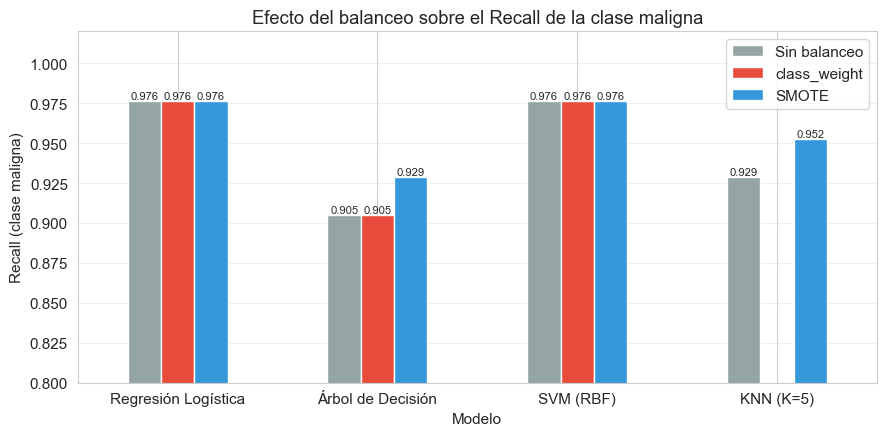

In [37]:
# Recall de la clase maligna: sin balanceo vs class_weight vs SMOTE
rec = res_bal[[c for c in res_bal.columns if c.startswith('Recall')]].copy()
rec.columns = [c.replace('Recall — ', '') for c in rec.columns]
ax = rec.plot(kind='bar', figsize=(9, 4.5), color=['#95a5a6', '#e74c3c', '#3498db'], rot=0)
ax.set_ylabel('Recall (clase maligna)'); ax.set_ylim(0.8, 1.02)
ax.set_title('Efecto del balanceo sobre el Recall de la clase maligna'); ax.grid(axis='y', alpha=0.3)
for p in ax.patches:
    if not np.isnan(p.get_height()):
        ax.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom', fontsize=8)
plt.tight_layout(); plt.show()

**Análisis del Ejercicio 2.**

| Modelo | Recall maligno sin balanceo | `class_weight` | SMOTE |
|---|---|---|---|
| Regresión Logística | 0.976 (1 FN) | 0.976 (1 FN) | 0.976 (1 FN) |
| Árbol de Decisión | 0.905 (4 FN) | 0.905 (4 FN) | 0.929 (3 FN) |
| SVM (RBF) | 0.976 (1 FN) | 0.976 (1 FN) | 0.976 (1 FN) |
| KNN (K=5) | 0.929 (3 FN) | no soporta | 0.952 (2 FN) |

*FN = malignos clasificados como benignos (de 42 malignos en test).*

- **El efecto del balanceo es pequeño:** el desbalance es moderado (≈ 63 % / 37 %) y el problema es casi linealmente separable, por lo que los modelos ya detectaban bien la clase maligna. Con `class_weight` el Recall **no mejora** en ningún modelo.
- **`class_weight` tiene un costo en Precision:** la Precision de la clase maligna baja en los tres modelos (Regresión Logística 0.976 → 0.911, SVM 0.976 → 0.932, Árbol 0.884 → 0.864). Es decir, se clasifican más benignos como malignos sin detectar más malignos.
- **SMOTE ayuda a los modelos más débiles:** sube el Recall del Árbol (0.905 → 0.929) y de KNN (0.929 → 0.952), reduciendo 1 falso negativo en cada uno, y no perjudica a la Regresión Logística ni al SVM (SVM mantiene Precision 0.976).
- **Conclusión:** en este dataset SMOTE es preferible a `class_weight`, ya que mejora o mantiene el Recall sin sacrificar tanta Precision; aun así, las diferencias corresponden a 1 caso de 42, así que son orientativas. En un problema médico conviene priorizar el Recall de la clase maligna, y para eso el SVM y la Regresión Logística ya son los mejores incluso sin balanceo.

---
### Ejercicio 3 — Dataset propio: Diabetes (Pima Indians, Kaggle/UCI)
Dataset de clasificación binaria con **768 registros** (mín. 500) y **8 features** (mín. 5). La clase de interés es `Outcome = 1` (con diabetes, 34.9 % de los datos). Se aplican los 4 modelos de la sesión más **Random Forest como modelo adicional**, con métricas, curvas ROC, matriz de selección y justificación del mejor modelo.



In [ ]:
import os, time, subprocess, sys
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_curve, auc, confusion_matrix)

try:
    df_d = pd.read_csv('diabetes.csv')
    print("-> Dataset 'diabetes.csv' cargado exitosamente desde la carpeta local.")
except FileNotFoundError:
    raise FileNotFoundError("No se encontró 'diabetes.csv'. Colócalo en la misma carpeta que el notebook "
                            "(o ajusta la ruta) y vuelve a ejecutar esta celda.")

print(f'Registros: {df_d.shape[0]} | Features: {df_d.shape[1]-1} | Nulos: {int(df_d.isna().sum().sum())}')
print('Distribución de la clase objetivo (Outcome):')
print(df_d['Outcome'].value_counts().rename({0: 'Sin diabetes (0)', 1: 'Con diabetes (1)'}))

X_d = df_d.drop(columns='Outcome')
y_d = df_d['Outcome']          # 1 = con diabetes (clase de interés / positiva)

# Misma partición que en el resto del trabajo: 80/20 estratificada
X_tr_d, X_te_d, y_tr_d, y_te_d = train_test_split(X_d, y_d, test_size=0.2, random_state=42, stratify=y_d)
print(f'\nTrain: {X_tr_d.shape[0]} | Test: {X_te_d.shape[0]} ({int(y_te_d.sum())} con diabetes)')

def metricas(model, X_te, y_te):
    """Métricas en test para la clase positiva (1 = diabetes)."""
    y_pred = model.predict(X_te)
    if hasattr(model, 'predict_proba'):
        score = model.predict_proba(X_te)[:, 1]
    else:
        score = model.decision_function(X_te)
    fpr, tpr, _ = roc_curve(y_te, score)
    return {'Accuracy': accuracy_score(y_te, y_pred),
            'Precision': precision_score(y_te, y_pred, zero_division=0),
            'Recall': recall_score(y_te, y_pred),
            'F1-Score': f1_score(y_te, y_pred),
            'ROC-AUC': auc(fpr, tpr)}, fpr, tpr

-> Dataset 'diabetes.csv' cargado exitosamente desde la carpeta local.
Registros: 768 | Features: 8 | Nulos: 0
Distribución de la clase objetivo (Outcome):
Outcome
Sin diabetes (0)    500
Con diabetes (1)    268
Name: count, dtype: int64

Train: 614 | Test: 154 (54 con diabetes)


Los modelos sensibles a la escala (Regresión Logística, SVM, KNN) usan datos estandarizados; Árbol y Random Forest usan los datos originales.

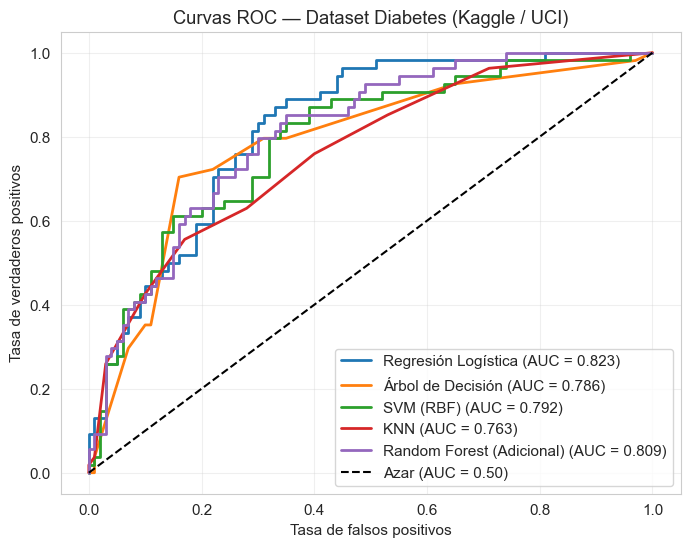

=== MÉTRICAS EN TEST ===


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Modelo,,,,,
Regresión Logística,0.7143,0.6087,0.5185,0.5600,0.8230
Árbol de Decisión,0.7922,0.7037,0.7037,0.7037,0.7858
SVM (RBF),0.7532,0.6600,0.6111,0.6346,0.7924
KNN,0.7338,0.6383,0.5556,0.5941,0.7628
Random Forest (Adicional),0.7273,0.6429,0.5000,0.5625,0.8093


In [39]:
# Scaler ajustado solo con train (para los modelos sensibles a la escala)
scaler_k = StandardScaler()
X_tr_sc = scaler_k.fit_transform(X_tr_d)
X_te_sc = scaler_k.transform(X_te_d)

# 4 modelos de la sesión + 1 adicional (Random Forest)
modelos_kaggle = {
    'Regresión Logística': LogisticRegression(random_state=42),
    'Árbol de Decisión': DecisionTreeClassifier(max_depth=5, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=9),
    'Random Forest (Adicional)': RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
}

resultados_k, tiempos = [], {}
fig, ax = plt.subplots(figsize=(8, 6))
for name, model in modelos_kaggle.items():
    sin_escala = 'Árbol' in name or 'Random' in name
    X_tr = X_tr_d if sin_escala else X_tr_sc
    X_te = X_te_d if sin_escala else X_te_sc

    t0 = time.perf_counter(); model.fit(X_tr, y_tr_d); model.predict(X_te)
    tiempos[name] = time.perf_counter() - t0

    m, fpr, tpr = metricas(model, X_te, y_te_d)
    ax.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {m['ROC-AUC']:.3f})")
    resultados_k.append({'Modelo': name, **{k: round(v, 4) for k, v in m.items()}})

ax.plot([0, 1], [0, 1], 'k--', label='Azar (AUC = 0.50)')
ax.set_xlabel('Tasa de falsos positivos'); ax.set_ylabel('Tasa de verdaderos positivos')
ax.set_title('Curvas ROC — Dataset Diabetes (Kaggle / UCI)')
ax.legend(loc='lower right'); plt.grid(True, alpha=0.3); plt.show()

res_k = pd.DataFrame(resultados_k).set_index('Modelo')
print('=== MÉTRICAS EN TEST ===')
display(res_k)

In [40]:
# Matriz de selección: criterios medidos (rendimiento, tiempo) + criterios cualitativos
cualitativos = pd.DataFrame({
    'Interpretabilidad':   ['★★★★☆', '★★★★★', '★★☆☆☆', '★★★☆☆', '★★☆☆☆'],
    'Escalabilidad':       ['★★★★★', '★★★★☆', '★★☆☆☆', '★★☆☆☆', '★★★★☆'],
    'Robustez a outliers': ['★★★☆☆', '★★★★☆', '★★★★☆', '★★☆☆☆', '★★★★★'],
}, index=res_k.index)

matriz = res_k[['Recall', 'F1-Score', 'ROC-AUC']].copy()
matriz['Tiempo train+pred (s)'] = pd.Series(tiempos).round(4)
matriz = matriz.join(cualitativos)
# Ranking global por rendimiento (promedio de posiciones en Recall, F1 y AUC; 1 = mejor)
matriz['Ranking rendimiento'] = res_k[['Recall', 'F1-Score', 'ROC-AUC']].rank(ascending=False).mean(axis=1).round(2)
print('=== MATRIZ DE SELECCIÓN DE MODELOS ===')
display(matriz.sort_values('Ranking rendimiento'))

=== MATRIZ DE SELECCIÓN DE MODELOS ===


,Recall,F1-Score,ROC-AUC,Tiempo train+pred (s),Interpretabilidad,Escalabilidad,Robustez a outliers,Ranking rendimiento
Modelo,,,,,,,,
Árbol de Decisión,0.7037,0.7037,0.7858,0.0084,★★★★★,★★★★☆,★★★★☆,2.00
SVM (RBF),0.6111,0.6346,0.7924,0.0670,★★☆☆☆,★★☆☆☆,★★★★☆,2.33
Regresión Logística,0.5185,0.5600,0.8230,0.0066,★★★★☆,★★★★★,★★★☆☆,3.33
KNN,0.5556,0.5941,0.7628,0.0068,★★★☆☆,★★☆☆☆,★★☆☆☆,3.67
Random Forest (Adicional),0.5000,0.5625,0.8093,0.2230,★★☆☆☆,★★★★☆,★★★★★,3.67


**Justificación del mejor modelo.**

| Modelo | Accuracy | Recall | F1 | ROC-AUC |
|---|---|---|---|---|
| Regresión Logística | 0.714 | 0.519 | 0.560 | **0.823** |
| Árbol de Decisión | **0.792** | **0.704** | **0.704** | 0.786 |
| SVM (RBF) | 0.753 | 0.611 | 0.635 | 0.792 |
| KNN | 0.734 | 0.556 | 0.594 | 0.763 |
| Random Forest | 0.727 | 0.500 | 0.563 | 0.809 |

1. **Criterio de selección:** al ser un problema médico de detección, la métrica prioritaria es el **Recall** de la clase con diabetes (minimizar falsos negativos), apoyado por F1 y ROC-AUC.
2. **Modelo elegido: Árbol de Decisión.** Es el mejor en Recall (0.704), F1 (0.704) y Accuracy (0.792), lidera el ranking de rendimiento de la matriz de selección (2.00, seguido de SVM con 2.33), es el más interpretable (sus reglas se pueden explicar a un médico) y es rápido de entrenar.
3. **Por qué no los demás:** la Regresión Logística tiene el mejor AUC (0.823) pero detecta solo la mitad de los casos con el umbral por defecto; Random Forest, pese a un AUC alto (0.809), tiene el Recall más bajo (0.500); KNN es el más débil y el menos robusto a outliers.
4. **Mejoras a probar:** como el dataset está desbalanceado (65 % / 35 %), usar `class_weight='balanced'` o ajustar el umbral de decisión permitiría aumentar el Recall de los modelos que hoy detectan menos de la mitad de los casos (Regresión Logística, Random Forest).
5. **Limitaciones:** el test tiene solo 154 muestras (54 positivos): una diferencia de 3–4 pacientes cambia las métricas, y el Árbol es inestable (cambia con otra partición). Además, en este dataset los ceros de `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin` y `BMI` son en realidad datos faltantes (374 ceros en `Insulin`, 227 en `SkinThickness`); imputarlos probablemente mejoraría a los modelos basados en distancias (KNN, SVM). Conviene validar la elección con validación cruzada repetida.

---
*Ingeniería del Conocimiento (ISO56B) — UNCP — 2026-II*